<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
# !pip install pandas
# !pip install matplotlib
# !pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


Text(2, 12000, 'Most respondents are in software development')

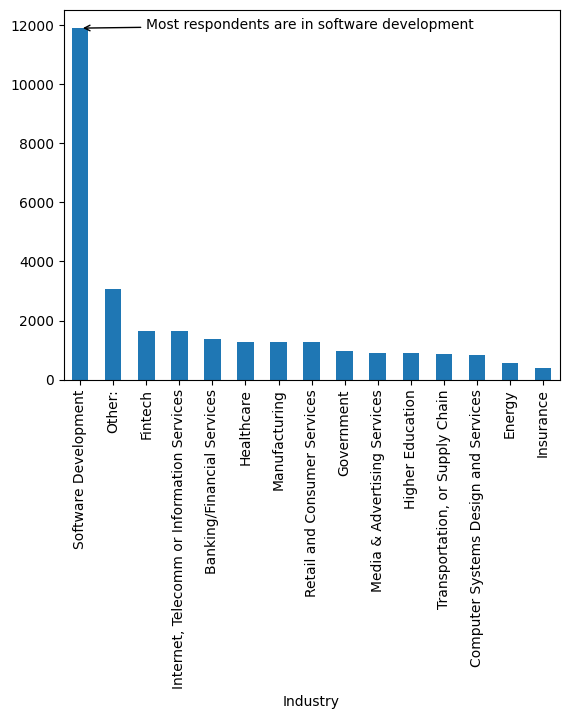

In [3]:
df['Industry'].value_counts().plot(kind='bar')
plt.annotate('Most respondents are in software development',
             xy = (0, 11900),
             xytext = (2, 12000),
             arrowprops=dict(arrowstyle='->'),
             va = 'center')

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [4]:
print('Mean:', df['ConvertedCompYearly'].mean())
print('Median:', df['ConvertedCompYearly'].median())
print('Std Dev:', df['ConvertedCompYearly'].std())

Mean: 86155.28726264134
Median: 65000.0
Std Dev: 186756.97308629757


In [5]:
df['ConvertedCompYearly'].describe()

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

In [6]:
upper_lim = df['ConvertedCompYearly'].describe()['75%'] + df['ConvertedCompYearly'].std() * 3
ccy_exceed = df['ConvertedCompYearly'][df['ConvertedCompYearly'] > upper_lim]
print(f'Upper Limit: {upper_lim}\n\nExceeding 3 std dev above:\n{ccy_exceed}')

Upper Limit: 668242.4192588928

Exceeding 3 std dev above:
828      1000000.0
1932      945000.0
2171      750000.0
2187     2000000.0
2316     1000000.0
           ...    
38219    1000000.0
39643    1300000.0
40066     800000.0
40952     750000.0
41027     700000.0
Name: ConvertedCompYearly, Length: 84, dtype: float64


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


 IQR: 75259.5
 Upper Bounds:237216.75
 Lower Bounds:26191.5



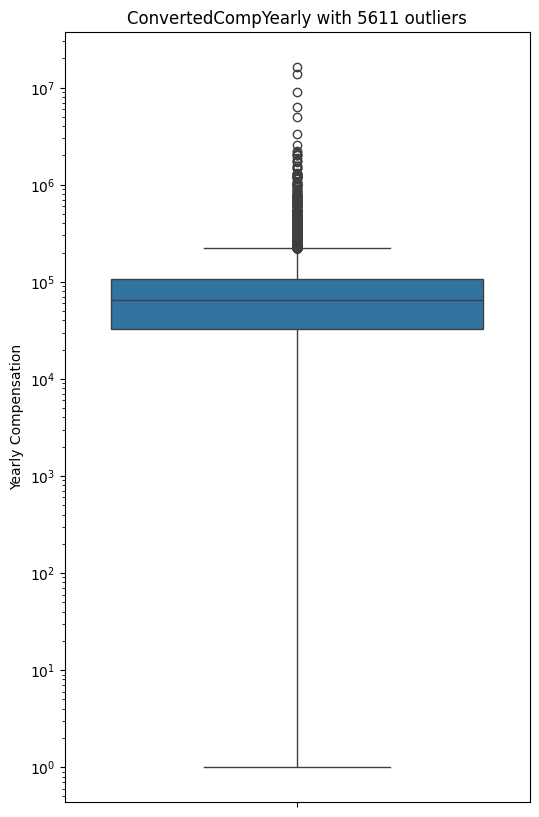

In [7]:
ccy_q1 = df['ConvertedCompYearly'].describe()['25%']
ccy_q3 = df['ConvertedCompYearly'].describe()['75%']
ccy_iqr = ccy_q3 - ccy_q1
upper_bounds = ccy_iqr + ccy_q3 * 1.5
lower_bounds = ccy_iqr - ccy_q1 * 1.5
ccy_outliers = df['ConvertedCompYearly'][(df['ConvertedCompYearly'] < lower_bounds) | (df['ConvertedCompYearly'] > upper_bounds)]
print(f' IQR: {ccy_iqr}\n Upper Bounds:{upper_bounds}\n Lower Bounds:{lower_bounds}\n')

plt.figure(figsize = (6,10))
sns.boxplot(df['ConvertedCompYearly'])
plt.ylabel('Yearly Compensation')
plt.title(f'ConvertedCompYearly with {ccy_outliers.count()} outliers')
plt.yscale('log')

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [8]:
ccy_no_outliers = df['ConvertedCompYearly'][(df['ConvertedCompYearly'] > lower_bounds) & (df['ConvertedCompYearly'] < upper_bounds)]
print(f' IQR: {ccy_iqr}\n Upper Bounds:{upper_bounds}\n Lower Bounds:{lower_bounds}\n')
print(ccy_no_outliers.describe())

 IQR: 75259.5
 Upper Bounds:237216.75
 Lower Bounds:26191.5

count     17824.000000
mean      88902.569513
std       47041.271152
min       26215.000000
25%       52853.000000
50%       76779.000000
75%      115000.000000
max      237000.000000
Name: ConvertedCompYearly, dtype: float64


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [9]:
df_age = df.drop(df[df['Age'] == 'Prefer not to say'].index)  # drop rows without an age
df_age['Age'] = df_age['Age'].replace('Under 18 years old', str(17))  # replace values with 17
df_age['Age'] = df_age['Age'].replace('65 years or older', str(65)) # replace values with 65
df_age['Age'] = df_age['Age'].str[0:2] # only keep first two characters of values
df_age['Age'] = df_age['Age'].astype(int) # convert all values to integers
df_age['Age'].value_counts()

Age
25    23911
35    14942
18    14098
45     6249
55     2575
17     2568
65      772
Name: count, dtype: int64

In [10]:
df_age.corr(numeric_only=True)

,ResponseId,Age,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
ResponseId,1.000000,-0.036823,-0.000000,0.012618,-0.002543,-0.015826,-0.014214,-0.002071,0.002049,-0.002748,0.001858,-0.005374,-0.005954,-0.008429,0.002690
Age,-0.036823,1.000000,-0.002973,0.855632,-0.028839,-0.075388,-0.101374,-0.051301,-0.081322,-0.046161,-0.081474,-0.113683,-0.106993,0.119497,0.069895
CompTotal,-0.000000,-0.002973,0.000000,0.028791,-0.004892,-0.002719,-0.003033,-0.006313,-0.005894,-0.004585,-0.004495,-0.003199,-0.003046,0.080464,-0.015774
WorkExp,0.012618,0.855632,0.028791,1.000000,-0.026545,-0.066776,-0.104391,-0.064473,-0.100777,-0.046744,-0.088080,-0.113251,-0.108048,0.154188,0.097581
JobSatPoints_1,-0.002543,-0.028839,-0.004892,-0.026545,1.000000,0.446022,0.634020,0.618927,0.603409,0.627714,0.598033,0.585362,0.608060,0.020359,0.094464
JobSatPoints_4,-0.015826,-0.075388,-0.002719,-0.066776,0.446022,1.000000,0.526343,0.449338,0.459402,0.438877,0.472763,0.499413,0.528500,0.018075,0.029592
JobSatPoints_5,-0.014214,-0.101374,-0.003033,-0.104391,0.634020,0.526343,1.000000,0.614003,0.607982,0.630436,0.619848,0.643587,0.691132,-0.023294,0.049220
JobSatPoints_6,-0.002071,-0.051301,-0.006313,-0.064473,0.618927,0.449338,0.614003,1.000000,0.692272,0.645123,0.632425,0.592532,0.604654,-0.008561,0.051382
JobSatPoints_7,0.002049,-0.081322,-0.005894,-0.100777,0.603409,0.459402,0.607982,0.692272,1.000000,0.698292,0.659770,0.642948,0.618587,-0.036413,0.038372
JobSatPoints_8,-0.002748,-0.046161,-0.004585,-0.046744,0.627714,0.438877,0.630436,0.645123,0.698292,1.000000,0.656029,0.617454,0.625301,-0.011083,0.058317


In [11]:
df_age[['Age','WorkExp']].corr()

,Age,WorkExp
Age,1.000000,0.855632
WorkExp,0.855632,1.000000


<Axes: >

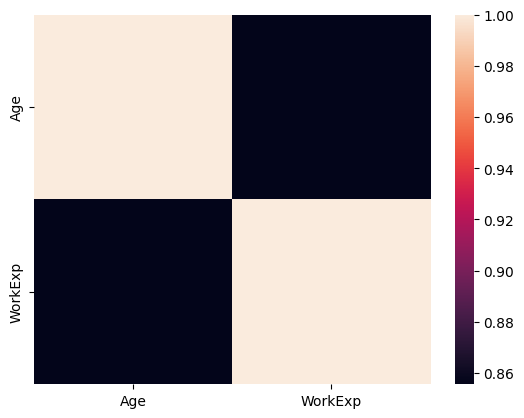

In [12]:
sns.heatmap(df_age[['Age','WorkExp']].corr())

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
